# TODO

- A better way to do this is to set a unique impact function id and have the measure at each site change the impact function instead of a new hazard

# Analysis goals

- CB analysis of changing the canopy composition of a given plantation

## 0 - Initial parameters

In [1]:
from pathlib import Path
import os

# Define output and input directories
INPUT_DIR = Path("/Users/viggo/Documents/Programming/Consult/UNU/data")
OUTPUT_DIR = Path("/Users/viggo/Documents/Programming/Consult/UNU/output")

# Define the hazard type
hazard_type = 'Tmax' #'VPD' or 'Tmax' (Temperature)

# Define the crop type
# crop_type = 'coffee' # 'banana' or 'cacao'

# Define the country
# country = 'MEX'  # 'DOM', 'MEX'

# Define the future scenario ( Use 'plus2C' for 2 degrees Celsius increase for the hazard part)
future_climate_scenario = 'plus2C' # 

# Define the present year and the future year
present_year = 2020
future_year = 2050


## 1 - Canopy compositions

In [2]:
# read canopy_composition.xlsx
file = INPUT_DIR / "canopy_composition.xlsx"

# get the number of sheets in the Excel file apart from the 'Current' sheet
import pandas as pd
file = INPUT_DIR / "canopy_composition.xlsx"
canopy_comps = pd.ExcelFile(file).sheet_names

# Create a dictionary to hold the canopy composition data
canopy_composition_dict = {}
for sheet in canopy_comps:
    canopy_composition_dict[sheet] = pd.read_excel(file, sheet_name=sheet)

In [3]:
# Sort the canopy composition data by the 'Latitude' and 'Longitude' columns
for sheet, df in canopy_composition_dict.items():
    if 'Latitude' in df.columns and 'Longitude' in df.columns:
        canopy_composition_dict[sheet] = df.sort_values(by=['Latitude', 'Longitude'])

# Modify the DataFrame to match the expected format for Exposures (Perhaps this should done in an early step or manually)
def modify_canopy_crop_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Rename columns
    df.rename(columns={
        "Latitude": "latitude",
        "Longitude": "longitude"
    }, inplace=True)

    # Generate unique site_id
    df["site_id"] = df.groupby(["latitude", "longitude"]).ngroup()

    return df

# Modify the canopy composition dataframes
for sheet, df in canopy_composition_dict.items():
    canopy_composition_dict[sheet] = modify_canopy_crop_df(df)

## 2 - Exposure

In [4]:
# Load the function generate_typical_plot_with_elevation from the make_exposure notebook (later on we will import from a utils)
#%run ../make_exposure.ipynb

### 2.1 - The canopy_crop_df

Give each site a site id 

In [5]:
from climada.entity import Exposures
from tabulate import tabulate
import pandas as pd


# Take the Current canopy composition as the baseline
df = canopy_composition_dict['Current']

print(f'Original DataFrame:')
print(tabulate(df.head(), headers='keys', tablefmt='grid'))

Original DataFrame:
+----+----------+------------------+--------------------+-------------------+-------------+---------------------+------------------------+------------+-------------+-----------------+-----------+
|    | System   |   Plot size (ha) | Species            | Scientific name   |   Plants/ha |   Yield (t/ha/year) |   Per-tree shading (%) |   latitude |   longitude |   Elevation (m) |   site_id |
+====+==========+==================+====================+===================+=============+=====================+========================+============+=============+=================+===========+
|  0 | Coffee   |                1 | Coffee (main crop) | Coffea arabica    |         nan |                0.73 |                  nan   |    17.3205 |    -93.1084 |             734 |         0 |
+----+----------+------------------+--------------------+-------------------+-------------+---------------------+------------------------+------------+-------------+-----------------+-----------+


Make the exposure and calcualte the tree shade for each site

In [6]:
# Function to create an Exposures object from the canopy crop DataFrame
def make_exposure_of_canopy_crop_df(canopy_crop_df: pd.DataFrame, value_unit: str = 'USD') -> tuple[Exposures, pd.DataFrame]:
    df = canopy_crop_df.copy()

    # Calculate production
    df["Production (t)"] = df["Plot size (ha)"] * df["Yield (t/ha/year)"]

    # Assign price only for coffee
    coffee_price_per_ton = 3200
    df["price (USD/t)"] = df["Scientific name"].apply(
        lambda x: coffee_price_per_ton if x == "Coffea arabica" else None
    )

    # Compute value (USD)
    df["value"] = df["Production (t)"] * df["price (USD/t)"]

    # Tree shade normalization and aggregation
    max_trees_per_ha = 144
    df['Per-tree shading (%)'] /= max_trees_per_ha
    df['Shade contribution (%)'] = df['Per-tree shading (%)'] * df['Plants/ha'] * df['Plot size (ha)']
    df['Tree Shade (%)'] = df.groupby("site_id")['Shade contribution (%)'].transform("sum")
    df['canopy_cover'] = df['Tree Shade (%)']

    # Only store values not nan
    df = df[df['value'].notna()]

    # Create exposure object
    exp = Exposures(df)
    exp.value_unit = value_unit
    exp.check()

    return exp

# Step 1: Prepare the data
canopy_crop_df = modify_canopy_crop_df(df)

# Step 2: Generate the exposure
exp = make_exposure_of_canopy_crop_df(canopy_crop_df)


print("Exposure DataFrame:")
print(tabulate(exp.gdf.head(), headers="keys", tablefmt="grid"))

2025-07-25 23:23:42,745 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
Exposure DataFrame:
+----+----------+------------------+--------------------+-------------------+-------------+---------------------+------------------------+-----------------+-----------+------------------+-----------------+---------+--------------------------+------------------+----------------+----------------------------------------------+
|    | System   |   Plot size (ha) | Species            | Scientific name   |   Plants/ha |   Yield (t/ha/year) |   Per-tree shading (%) |   Elevation (m) |   site_id |   Production (t) |   price (USD/t) |   value |   Shade contribution (%) |   Tree Shade (%) |   canopy_cover | geometry                                     |
+====+==========+==================+====================+===================+=============+=====================+========================+=================+===========+==================+=================

Store unique site ids to iterate through later on

In [24]:
unique_site_ids = exp.gdf['site_id'].unique()
print(f"Unique site IDs: {unique_site_ids}")

Unique site IDs: [0]


## 3 – Hazard 


- Here we do it a little bit differetn then the common CLIMADA as each grid point has a uniquiew adaption measure given by the canopy level.
- We will need to store a current and a future hazard set which will be usefulle for the risk comaprisson over time and the CB analysis.
- We download both historical weather and future weather (which can be changed based on RCP levels)

### 3.1 - Download data

**Data Sources – Terra climate**

https://www.climatologylab.org/terraclimate.html

🌡️ VPD – Vapour Pressure Deficit

We model Vapour Pressure Deficit (VPD) as a key climate hazard, similar to the paper Kath et al. (2022), Nature Food. The study provides a vulnerability curve linking mean VPD during the growing season to yield impacts for coffee.

We calculate the mean VPD over the crop-specific growing season: Mexico: June to December

Download the data 

Load the raster files to generate present and future hazard

📂 Loading 37 files for variable 'tmax'...
📆 Filtering to months: [5, 6, 7, 8, 9, 10, 11]
🧮 Aggregating by year using 'mean'...
📌 Reshaping data to [year, lat*lon] array...
🔄 Replacing NaNs with 0.0...
🧱 Converting to sparse matrix...
🗺️ Extracting lat/lon centroids...
📦 Creating Hazard object...
📂 Loading 30 files for variable 'tmax'...
📆 Filtering to months: [5, 6, 7, 8, 9, 10, 11]
🧮 Aggregating by year using 'mean'...
📌 Reshaping data to [year, lat*lon] array...
🔄 Replacing NaNs with 0.0...
🧱 Converting to sparse matrix...
🗺️ Extracting lat/lon centroids...
📦 Creating Hazard object...


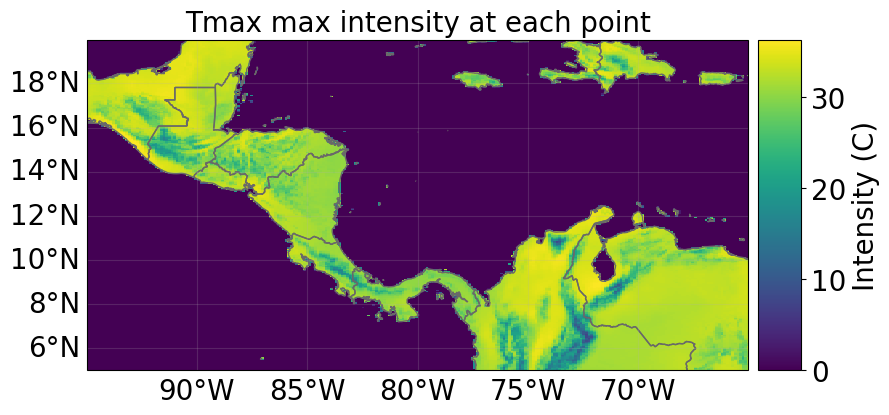

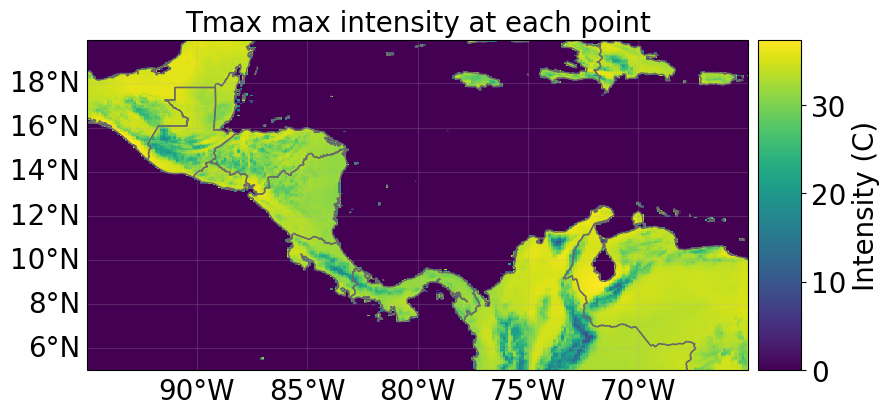

In [7]:
from utils_cb import create_hazard_from_nc_files
from climada.hazard import Hazard

# Determine the corresponding parameters for the hazard type
nc_files = {'present': [], 'future': []}
haz_dict = {'present': Hazard, 'future': Hazard}

if hazard_type == 'VPD':
    agg = 'mean'
    varname = 'vpd'
    nc_files['present'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_vpd_*_CA.nc"))
    nc_files['future'] = sorted(INPUT_DIR.glob(f"terra_climate/TerraClimate_{future_climate_scenario}_vpd_*_CA.nc"))
    units = 'kPa'
    months = [5, 6, 7, 8, 9, 10, 11]  # April to November
elif hazard_type == 'Tmax':
    agg = 'mean'
    varname = 'tmax'
    nc_files['present'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_tmax_*_CA.nc"))
    nc_files['future'] = sorted(INPUT_DIR.glob(f"terra_climate/TerraClimate_{future_climate_scenario}_tmax_*_CA.nc"))
    units = 'C'
    months = [5, 6, 7, 8, 9, 10, 11] # April to November


# Store the hazard type and parameters in a dictionary
for key in nc_files:
    haz_dict[key] = create_hazard_from_nc_files(
                        nc_files[key],
                        varname=varname,
                        haz_type=hazard_type,
                        units=units,
                        agg=agg,
                        months=months,
                        nan_replacement=0.0  # Use NaN to keep sparse matrix
                    )
    # Plot the hazard object
    haz_dict[key].plot_intensity(0)


## 4 – Impact function (Vulnerability)

As mentioned in Step 3, the vulnerability curve is sourced from the following study: [Kath et al. (2022), *Nature Food*](https://www.nature.com/articles/s43016-022-00614-8)



Make an impact function for each crop

<Axes: title={'center': 'Tmax 0: Tmax Empirical Yield Loss'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>

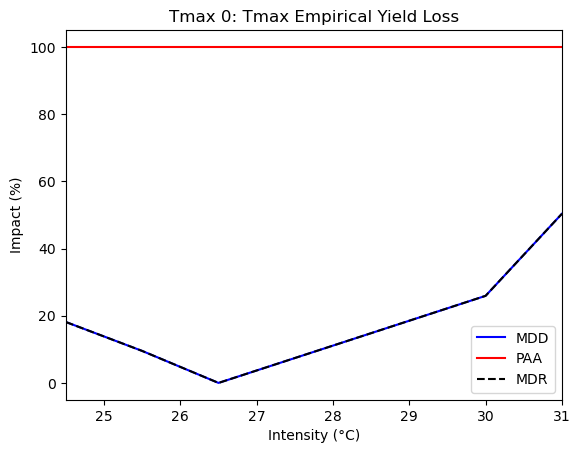

In [8]:
from utils_cb import impact_func_from_kath

import pandas as pd
import numpy as np
from climada.entity import ImpactFunc


# Make for coffe
if hazard_type.upper() == 'TMAX':
    impf = impact_func_from_kath(
        file_path= "tasmax_effect_approximation.csv",
        intensity_col="Mean_Tasmax_C",
        yield_col="Effect_Central",
        only_yield_losses=True,
        haz_type="Tmax",
        unit="°C",
        name="Tmax Empirical Yield Loss",
        if_id = 0
    )
elif hazard_type.upper() == 'VPD':
    impf = impact_func_from_kath(
        file_path= "vpd_effect_approximation.csv",
        intensity_col="Mean_VPD_kPa",
        yield_col="Effect_Central",
        only_yield_losses=True,
        haz_type="VPD",
        unit="kPa",
        name="VPD Empirical Yield Loss",
        if_id = 0
    )

# Plot the impact function
impf.plot()


In [9]:
from climada.entity import ImpactFuncSet

# Create a new ImpactFuncSet
impf_set = ImpactFuncSet([impf])

2025-07-25 23:24:28,100 - climada.entity.impact_funcs.impact_func_set - WARNING - Input ImpactFunc's id not set.


## 5 – Cooling of cananopy and baseline

Make the adjustment function

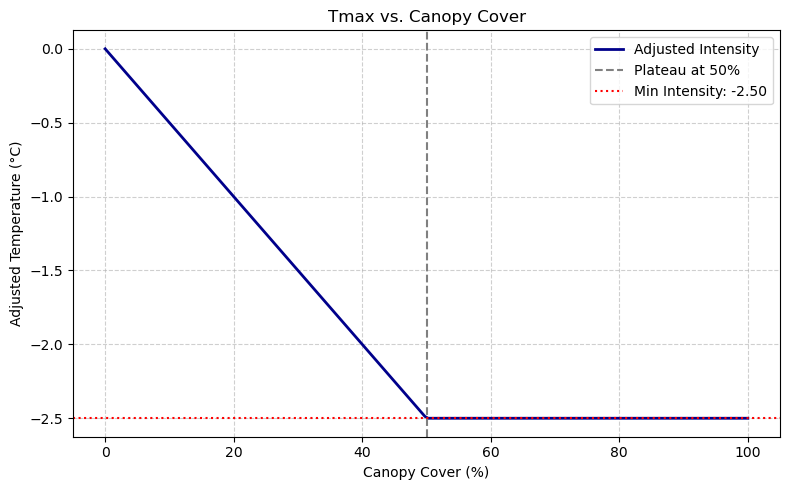

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Updated function definition
def helper_create_adj_func(max_cooling=2.5, plateau_at=50, sensitivity=None):
    """
    Creates an adjustment function for canopy cover effects on the intensity of a hazard.
    Args:
        max_cooling (float): Maximum cooling effect (°C or kPa).
        plateau_at (float): Canopy cover percentage at which the cooling effect plateaus.
        sensitivity (float, optional): Sensitivity factor for VPD reduction. If None, no
            sensitivity adjustment is applied.
    Returns:
        function: A function that takes a hazard intensity and canopy cover array
                  and returns the adjusted hazard intensity.
    """
    slope = -max_cooling / plateau_at

    def adjustment(intensity, canopy_cover):
        """Applies adjustment to hazard intensity based on canopy cover."""
        if not isinstance(canopy_cover, np.ndarray):
            canopy_cover = np.array(canopy_cover)
        canopy = np.clip(canopy_cover, 0, 100)
        temp_reduction = np.where(
            canopy <= plateau_at,
            slope * canopy,
            -max_cooling
        )
        if sensitivity is not None:
            reduction = -sensitivity * temp_reduction
        else:
            reduction = temp_reduction
        return intensity + reduction

    return adjustment

# Example for plotting
hazard_type = 'TMAX'  # 'TMAX' or 'VPD'
canopy = np.linspace(0, 100, 200)

if hazard_type.upper() == 'TMAX':
    base_intensity = 0  # °C
    adjust_fcn = helper_create_adj_func(max_cooling=2.5, plateau_at=50)
    ylabel = "Adjusted Temperature (°C)"
    title = "Tmax vs. Canopy Cover"
elif hazard_type.upper() == 'VPD':
    base_intensity = 0  # kPa
    adjust_fcn = helper_create_adj_func(max_cooling=3.0, plateau_at=50, sensitivity=0.15)
    ylabel = "Adjusted VPD (kPa)"
    title = "VPD vs. Canopy Cover"
else:
    raise ValueError("Unsupported hazard type")

# Calculate adjusted values
adj_intensity = adjust_fcn(base_intensity, canopy)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(canopy, adj_intensity, label="Adjusted Intensity", color="darkblue", linewidth=2)
plt.axvline(50, linestyle='--', color='gray', label="Plateau at 50%")
plt.axhline(adj_intensity[-1], linestyle=':', color='red', label=f'Min Intensity: {adj_intensity[-1]:.2f}')
plt.title(title)
plt.xlabel("Canopy Cover (%)")
plt.ylabel(ylabel)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


<Axes: title={'center': 'Tmax 1: Tmax Empirical Yield Loss'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>

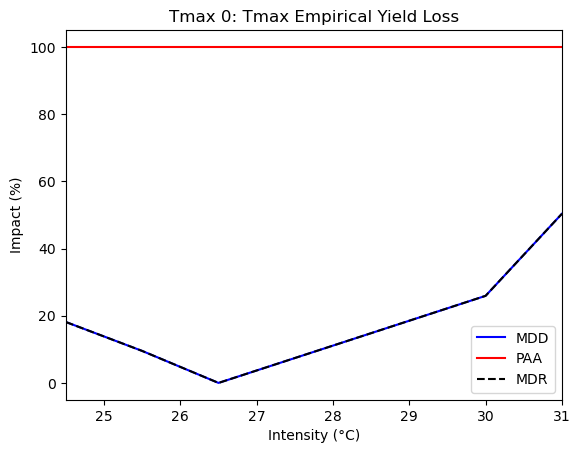

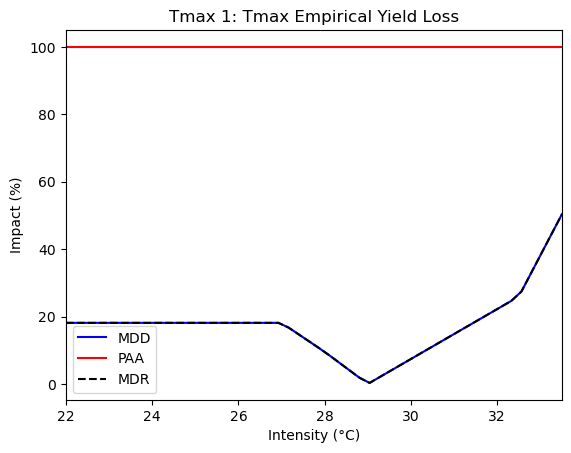

In [11]:
# Suppose you already have:
# - impf: the original impact function
# - adjust_fcn: a function like adjust_fcn(intensity, canopy)

import numpy as np
import copy

def adjust_impf_by_canopy(impf, adjust_fcn, new_id, current_canopy=50):
    """
    Adjust an impact function based on a canopy adjustment function.

    Parameters:
    -----------
    impf : ImpactFuncSet or compatible object
        Original impact function to be adjusted.
    adjust_fcn : function
        Function that modifies intensity based on canopy cover: f(intensity, canopy).
    new_id : int
        ID for the new adjusted impact function.
    current_canopy : float
        Canopy cover percentage to apply (default is 50).

    Returns:
    --------
    adj_impf : ImpactFunc object
        A copy of the original impact function with adjusted intensity and MDR.
    """
    # Copy the original impact function
    adj_impf = copy.deepcopy(impf)

    # Full original intensity range
    orig_intensity = impf.intensity
    orig_min, orig_max = orig_intensity.min(), orig_intensity.max()

    # Use fine spacing to assess max shift
    test_intensity = np.linspace(orig_min, orig_max, 500)
    adjusted = adjust_fcn(test_intensity, current_canopy)
    shift = adjusted - test_intensity
    max_shift = np.abs(shift).max()

    # Extend range to ensure coverage
    n_points = 50
    intensity_range = np.linspace(orig_min - max_shift, orig_max + max_shift, n_points)


    # Check paa logic
    if np.all(impf.paa == 1):
        adj_intensity = adjust_fcn(intensity_range, current_canopy)
        adjusted_mdr = impf.calc_mdr(adj_intensity)

        # Update impact function
        adj_impf.intensity = intensity_range
        adj_impf.mdd = adjusted_mdr
        adj_impf.paa = np.ones_like(intensity_range)
        adj_impf.id = new_id

    else:
        print('⚠️ Warning: impf.paa is not all ones, adjustment skipped.')

    return adj_impf

new_id = 1
adj_impf = adjust_impf_by_canopy(impf, adjust_fcn, new_id, current_canopy=50)

impf.plot()
adj_impf.plot()


Add the baseline impact function to the set

In [12]:
impf_set.append(adj_impf)

## Filter out the exposure here

## 6 – Adaptation Measures - What trees to plant?

ToDO:
- Make a function that generates a new canopy_df and exp_df based on the planting
- You either compare different canopy compsition
- You increase the canopy

- There are two ways of defeing the measure
    -  You either increase tress
    - canhege the compostion in another excele sheet

In [ ]:
site_id = 0  # Example site_id to filter

In [14]:
# Get the measure names from the canopy composition dictionary
measure_names = [meas_name for meas_name in canopy_composition_dict.keys() if meas_name != 'Current'] 

print(f"Available sheets in the Excel file: {measure_names}")

Available sheets in the Excel file: ['Alternative 1', 'Alternative 2', 'Alternative 3']


In [31]:
impf_set.get_ids()

{'Tmax': [0, 1, 2, 3, 4]}

In [ ]:
from climada.entity.measures import Measure, MeasureSet


# Define the measure set
meas_set = MeasureSet()

for impf_id, (canopy_name, canopy_df) in enumerate(canopy_composition_dict.items(), start=1):
    
    ## Make the exposure of the canopy crop DataFrame
    # Make the exposure of the canopy crop DataFrame
    exp = make_exposure_of_canopy_crop_df(canopy_df)
    # Get the current canopy cover
    if len(exp.gdf) == 1:
        current_canopy = exp.gdf['Tree Shade (%)'].values[0]
    else:
        print(f"Warning: More than one site_id found in the exposure DataFrame. Using the first one.")

    ## Make the impact function based on the canopy cover
    # Adjust the impact function based on the canopy cover
    adj_impf = adjust_impf_by_canopy(impf, adjust_fcn, new_id=impf_id, current_canopy=current_canopy)
    # add the adjusted impact function to the set
    impf_set.append(adj_impf)
    
    ## Make the measures 
    if canopy_name != 'Current':
        # Define the measure 
        meas =  Measure(
            name= canopy_name, # Name of the measure
            haz_type = hazard_type,
            color_rgb = np.random.rand(3,), # Give the measure a random color
            imp_fun_map = f'1to{impf_id}',  # Map the adjusted impact function to the hazard type
            # For the cost you can use canopy_composition_dict for the current measure name and the new exposure
        )
        print(meas.imp_fun_map)

        # Add the measure to the MeasureSet
        meas_set.append(meas)
        meas_set.check()



2025-07-25 23:57:35,114 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
2025-07-25 23:57:35,117 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
1to2
2025-07-25 23:57:35,120 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
1to3
2025-07-25 23:57:35,122 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
1to4


In [35]:
from climada.entity.measures import Measure, MeasureSet

# Define the measure set
meas_set = MeasureSet()

# Define each measure based on the canopy composition make a count for each measure name
for meas_id, meas_name in enumerate(measure_names, start=2):  # Start from 2 to avoid conflict with 'Current'

    # Make the impact function for the current measure
    canopy_df = canopy_composition_dict[meas_name]
    exp = make_exposure_of_canopy_crop_df(canopy_df)
    # Adjust the impact function for the current measure
    adj_impf = adjust_impf_by_canopy(impf, adjust_fcn, new_id=meas_id, current_canopy=50)

    # Define the measure 
    meas =  Measure(
        name= meas_name, # Name of the measure
        haz_type = hazard_type,
        color_rgb = np.random.rand(3,), # Give the measure a random color
        imp_fun_map = f'1to{meas_id}',  # Map the adjusted impact function to the hazard type
        # For the cost you can use canopy_composition_dict for the current measure name and the new exposure
    )
    print(meas.imp_fun_map)
    
    meas_set.append(meas)
    meas_set.check()

2025-07-25 23:57:07,741 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
1to2
2025-07-25 23:57:07,750 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
1to3
2025-07-25 23:57:07,760 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
1to4


Calulate the cost-benefit

Defeine the added canopy

In [ ]:
added_canopy = {
    '0': {
        'Guama': 1,
        'Bitter orange': 10,
        'Sweet orange': 4,
        'Sapote': 1
    }
}

Make a new canopy composition and exposure

In [ ]:
def add_tree_species_in_canopy(canopy_df: pd.DataFrame, added_canopy: dict) -> pd.DataFrame:
    import numpy as np

    updated_df = canopy_df.copy()

    for site_id_str, tree_dict in added_canopy.items():
        site_id = int(site_id_str)
        site_mask = updated_df["site_id"] == site_id

        if not site_mask.any():
            print(f"Warning: No data found for site_id {site_id}")
            continue

        for species_name, trees_to_add in tree_dict.items():
            if trees_to_add <= 0:
                continue

            # Find relevant rows
            match_mask = site_mask & (updated_df["Species"].str.lower() == species_name.lower())
            match_rows = updated_df[match_mask]

            if match_rows.empty:
                print(f"Warning: No rows found for species '{species_name}' in site {site_id}")
                continue

            total_plot_area = match_rows["Plot size (ha)"].sum()
            if total_plot_area <= 0:
                print(f"⚠️ Invalid plot size for species '{species_name}' at site {site_id}")
                continue

            # Distribute trees across rows proportionally
            for idx in match_rows.index:
                plot_size = updated_df.at[idx, "Plot size (ha)"]
                share = plot_size / total_plot_area
                additional_trees = share * trees_to_add
                additional_plants_per_ha = additional_trees / plot_size

                existing_plants_per_ha = updated_df.at[idx, "Plants/ha"]
                existing_plants_per_ha = existing_plants_per_ha if pd.notna(existing_plants_per_ha) else 0

                updated_df.at[idx, "Plants/ha"] = existing_plants_per_ha + additional_plants_per_ha

                # Recalculate production
                yield_rate = updated_df.at[idx, "Yield (t/ha/year)"]
                updated_df.at[idx, "Production (t)"] = plot_size * yield_rate if pd.notna(yield_rate) else np.nan

                # Recalculate value (only for coffee)
                if updated_df.at[idx, "Scientific name"] == "Coffea arabica":
                    price = 3200
                    updated_df.at[idx, "price (USD/t)"] = price
                    updated_df.at[idx, "value"] = price * updated_df.at[idx, "Production (t)"]
                else:
                    updated_df.at[idx, "price (USD/t)"] = None
                    updated_df.at[idx, "value"] = None

    return updated_df


In [ ]:
extended_canopy_crop_df = add_tree_species_in_canopy(canopy_crop_df, added_canopy)

print(f"Previous Canopy Crop DataFrame:\n{tabulate(canopy_crop_df, headers='keys', tablefmt='grid')}\n")
print(f"Extended Canopy Crop DataFrame:\n{tabulate(extended_canopy_crop_df, headers='keys', tablefmt='grid')}\n")

# Step 2: Generate the exposure
new_exp = make_exposure_of_canopy_crop_df(extended_canopy_crop_df)
print("Exposure DataFrame:")
print(f'New Exposure DataFrame:\n{tabulate(new_exp.gdf.head(), headers="keys", tablefmt="grid")}\n')

In [ ]:
imp_fun_map (str): change of impact function id, e.g. ‘1to3’

### 5.2 – Calculate the costs

Make a dsicount rate to use

In [ ]:
from climada.entity import DiscRates

year_range = np.arange( present_year, future_year + 1)
n_years = len(year_range)
annual_discount_zero = np.zeros(n_years)
annual_discount_stern = np.ones(n_years) * 0.014

discount_zero = DiscRates(year_range, annual_discount_zero)
discount_stern = DiscRates(year_range, annual_discount_stern)

# Create the entity for the present climate scenario
disc_rate = discount_stern  # Use the zero discount rate for the present scenario

disc_rate.plot()

Get the cost and revenue estimates

In [ ]:
# Import the canopy price data
file = INPUT_DIR / "Crop Price Data.xlsx"
costs_df = pd.read_excel(file, sheet_name="Costs")
revenues_df = pd.read_excel(file, sheet_name="Revenue")

print(f"Costs DataFrame:\n{tabulate(costs_df, headers='keys', tablefmt='grid')}\n")
print(f"Revenues DataFrame:\n{tabulate(revenues_df, headers='keys', tablefmt='grid')}\n")

Define the added canopy

In [ ]:
# Sample input: canopy definition per site id
added_canopy = {'0': {
    'Guama': 0,
    'Bitter orange': 1,
    'Sapote': 0,
}}

Calculate cashflows

In [ ]:
import pandas as pd

# Mapping from grouped/friendly names to actual species names in costs/revenues
canopy_to_cost_species = {
    "Guama": "Guama (Inga spp.)",
    "Breadfruit": "Cuban Pine Nut (Gliricidia sepium)",
    "Bitter orange": "Citrus fruits",
    "Sweet orange": "Citrus fruits",
    "Avocado": "Avocado",
    "Sapote": "Sapodilla",
    "Chestnut": "Chestnut"
}

def calculate_cashflows(costs_df, revenue_df, added_canopy, site, start_year, end_year):
    raw_species_counts = added_canopy[site]

    # Remap species from canopy names → grouped names (for costs/revenues)
    species_counts = {}
    for canopy_species, count in raw_species_counts.items():
        grouped_species = canopy_to_cost_species.get(canopy_species)
        if not grouped_species:
            print(f"Warning: No grouped name found for '{canopy_species}' — skipping.")
            continue
        species_counts[grouped_species] = species_counts.get(grouped_species, 0) + count

    # Filter cost/revenue tables
    cost_species = costs_df[costs_df["Species"].isin(species_counts.keys())]
    revenue_species = revenue_df[revenue_df["Species"].isin(species_counts.keys())]

    results = []

    for year in range(start_year, end_year + 1):
        total_cost = 0
        total_revenue = 0
        relative_year = year - start_year + 1

        for species, count in species_counts.items():
            if count == 0:
                continue

            # COST
            cost_row = cost_species[(cost_species["Species"] == species) & (cost_species["Year"] == relative_year)]
            if not cost_row.empty:
                cost = cost_row["Total Cost (RD$)"].values[0]
            else:
                past = cost_species[(cost_species["Species"] == species) & (cost_species["Year"] <= relative_year)]
                cost = past.sort_values("Year").iloc[-1]["Total Cost (RD$)"] if not past.empty else 0
            total_cost += count * cost

            # REVENUE
            rev_row = revenue_species[revenue_species["Species"] == species]
            if not rev_row.empty:
                fruit_start_year = start_year + rev_row["Time Until Fruits"].values[0] - 1
                if year >= fruit_start_year:
                    revenue = rev_row["Total production per plant (RD$/plant)"].values[0]
                    total_revenue += count * revenue

        results.append((year, total_cost, total_revenue))

    # Final cashflows DataFrame
    cashflows_df = pd.DataFrame(results, columns=["Year", "Costs", "Revenue"])
    cashflows_df["Costs"] = -cashflows_df["Costs"]
    cashflows_df["Netto"] = cashflows_df["Revenue"] + cashflows_df["Costs"]

    return cashflows_df



# Example usage
cashflows_df = calculate_cashflows(costs_df, revenues_df, added_canopy, site='0', start_year=present_year, end_year=future_year)
# Convert RD$ to USD (assuming 1 USD = 60 RD$)
rate_USD_to_RD = 60
cashflows_df["Costs"] /= rate_USD_to_RD
cashflows_df["Revenue"] /= rate_USD_to_RD
cashflows_df["Netto"] /= rate_USD_to_RD
print(f"Cashflows DataFrame:\n{tabulate(cashflows_df, headers='keys', tablefmt='grid')}\n")

# Net present value of costs
NPV_cost_measure = disc_rate.net_present_value(ini_year = cashflows_df['Year'].min(),
                                                end_year = cashflows_df['Year'].max(),
                                                val_years = cashflows_df['Netto'].values
                                                )
print(f"Net Present Value of Costs with Discount Rate: {NPV_cost_measure:.2f}")


Make a new exposure based on the new canopy structure

In [ ]:
def add_tree_species_in_canopy(canopy_df: pd.DataFrame, added_canopy: dict) -> pd.DataFrame:
    import numpy as np

    updated_df = canopy_df.copy()

    for site_id_str, tree_dict in added_canopy.items():
        site_id = int(site_id_str)
        site_mask = updated_df["site_id"] == site_id

        if not site_mask.any():
            print(f"Warning: No data found for site_id {site_id}")
            continue

        for species_name, trees_to_add in tree_dict.items():
            if trees_to_add <= 0:
                continue

            # Find relevant rows
            match_mask = site_mask & (updated_df["Species"].str.lower() == species_name.lower())
            match_rows = updated_df[match_mask]

            if match_rows.empty:
                print(f"Warning: No rows found for species '{species_name}' in site {site_id}")
                continue

            total_plot_area = match_rows["Plot size (ha)"].sum()
            if total_plot_area <= 0:
                print(f"⚠️ Invalid plot size for species '{species_name}' at site {site_id}")
                continue

            # Distribute trees across rows proportionally
            for idx in match_rows.index:
                plot_size = updated_df.at[idx, "Plot size (ha)"]
                share = plot_size / total_plot_area
                additional_trees = share * trees_to_add
                additional_plants_per_ha = additional_trees / plot_size

                existing_plants_per_ha = updated_df.at[idx, "Plants/ha"]
                existing_plants_per_ha = existing_plants_per_ha if pd.notna(existing_plants_per_ha) else 0

                updated_df.at[idx, "Plants/ha"] = existing_plants_per_ha + additional_plants_per_ha

                # Recalculate production
                yield_rate = updated_df.at[idx, "Yield (t/ha/year)"]
                updated_df.at[idx, "Production (t)"] = plot_size * yield_rate if pd.notna(yield_rate) else np.nan

                # Recalculate value (only for coffee)
                if updated_df.at[idx, "Scientific name"] == "Coffea arabica":
                    price = 3200
                    updated_df.at[idx, "price (USD/t)"] = price
                    updated_df.at[idx, "value"] = price * updated_df.at[idx, "Production (t)"]
                else:
                    updated_df.at[idx, "price (USD/t)"] = None
                    updated_df.at[idx, "value"] = None

    return updated_df


Define the added canopy

In [ ]:
added_canopy = {
    '0': {
        'Guama': 1,
        'Bitter orange': 10,
        'Sweet orange': 4,
        'Sapote': 1
    }
}

extended_canopy_crop_df = add_tree_species_in_canopy(canopy_crop_df, added_canopy)

print(f"Previous Canopy Crop DataFrame:\n{tabulate(canopy_crop_df, headers='keys', tablefmt='grid')}\n")
print(f"Extended Canopy Crop DataFrame:\n{tabulate(extended_canopy_crop_df, headers='keys', tablefmt='grid')}\n")

# Step 2: Generate the exposure
new_exp = make_exposure_of_canopy_crop_df(extended_canopy_crop_df)
print("Exposure DataFrame:")
print(f'New Exposure DataFrame:\n{tabulate(new_exp.gdf.head(), headers="keys", tablefmt="grid")}\n')


Define the measure